# NB07: Dietrich Pipeline Deep Dive v21

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


In [1]:
# @title CELL 3: NB07 CONFIG
TIER_SELECTION = [0,1,2]
CITY_FILTER = None #'Mariupol'
CITY_SELECTION = [CITY_FILTER] if CITY_FILTER else None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42


In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os, json
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-04-17 20:08:08
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:542: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     912.4/7452.0 GB (6539.6 GB free)
  GDrive (F:)     1622.8/3726.0 GB (2103.2 GB free)
  Local data      11504.8/14901.9 GB (3397.1 GB free)
  Data stack      1622.8/3726.0 GB (2103.2 GB free)
  WSL ext4        91.1/1006.9 GB (864.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: LOAD BUILDINGS + SHARED HELPERS

Loads ONLY bda_buildings.parquet (metadata). Each D-cell loads its own experiment parquet.


In [3]:
# @title CELL S0: LOAD BUILDINGS + SHARED HELPERS
import sys, importlib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("CELL S0: NB07 BUILDINGS + HELPERS")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

# load building metadata (per-tier)
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
df_bldg = load_tier_parquets(PARQUET_BUILDINGS_TIER_FMT, _tiers)
if CITY_FILTER:
    df_bldg = df_bldg[df_bldg['city'] == CITY_FILTER].copy()
df_bldg = df_bldg[df_bldg['damage_binary'] >= 0].copy()
print(f"  Buildings: {len(df_bldg)} ({CITY_FILTER or 'all cities'})")
print(f"  Damaged: {(df_bldg['damage_binary']==1).sum()}, Undamaged: {(df_bldg['damage_binary']==0).sum()}")
has_centroids = 'centroid_x' in df_bldg.columns and 'centroid_y' in df_bldg.columns
print(f"  Centroids in buildings parquet: {has_centroids}")

RF_PARAMS = {'n_estimators': 200, 'min_samples_leaf': 3, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'class_weight': 'balanced'}
DIETRICH_PAPER = {'auc': 0.813, 'f1': 0.749, 'precision': 0.671, 'recall': 0.846}
TARGET_COL = 'damage_binary'

# Dietrich-28: VV/VH x (min, max, mean, median, std, kurtosis, skewness) = 28
# only 'count' is a metadata stat that must be excluded
EXCLUDE_CARD_STATS = ['count']


def filter_card_cols(cols, dietrich28=False):
    """Filter card feature columns.

    Always excludes 'count' stats (observation count metadata, not backscatter).
    If dietrich28=True, also restricts to _mean zonal aggregate only,
    yielding exactly 2pol x 7stats x 2periods = 28 features.
    """
    filtered = []
    for c in cols:
        parts = c.split('__')
        if len(parts) < 4:
            continue
        stat_agg = parts[3]  # e.g. mean_mean, count_std, kurtosis_max
        stat_name = stat_agg.split('_')[0]
        if stat_name in EXCLUDE_CARD_STATS:
            continue
        if dietrich28:
            zonal_agg = stat_agg.split('_')[-1]
            if zonal_agg != 'mean':
                continue
        filtered.append(c)
    return filtered


def load_and_merge(parquet_fmt, bldg_df=None, include_centroids=False, **kwargs):
    """Load per-tier parquets and merge with building metadata. Returns df with damage_binary.
    parquet_fmt: tier fmt string (e.g. PARQUET_PREPOST_TIER_FMT).
    Extra kwargs passed to load_tier_parquets (e.g. window=7)."""
    if bldg_df is None:
        bldg_df = df_bldg
    df = load_tier_parquets(parquet_fmt, _tiers, **kwargs)
    if CITY_FILTER:
        df = df[df['city'] == CITY_FILTER].copy()
    merge_cols = ['building_id', 'city', TARGET_COL]
    if include_centroids:
        for cc in ['centroid_x', 'centroid_y']:
            if cc in bldg_df.columns and cc not in df.columns:
                merge_cols.append(cc)
    merge_cols = [c for c in merge_cols if c in bldg_df.columns]
    if TARGET_COL not in df.columns:
        df = df.merge(bldg_df[merge_cols].drop_duplicates(),
                      on=['building_id', 'city'], how='inner')
    elif include_centroids:
        extra = [c for c in merge_cols if c not in df.columns]
        if extra:
            df = df.merge(bldg_df[['building_id', 'city'] + extra].drop_duplicates(),
                          on=['building_id', 'city'], how='left')
    df = df[df[TARGET_COL] >= 0].copy()
    return df


def run_rf_cv(X, y, groups=None, n_folds=5, label=""):
    """Run RF with optional GroupKFold, return dict with metrics."""
    rf = RandomForestClassifier(**RF_PARAMS)
    if groups is not None and len(np.unique(groups)) >= n_folds:
        splitter = GroupKFold(n_splits=min(n_folds, len(np.unique(groups))))
        splits = list(splitter.split(X, y, groups))
    else:
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
        splits = list(splitter.split(X, y))

    y_proba = np.full(len(y), np.nan)
    for train_idx, test_idx in splits:
        rf_c = RandomForestClassifier(**RF_PARAMS)
        imp = SimpleImputer(strategy='median')
        X_tr = imp.fit_transform(X[train_idx])
        X_te = imp.transform(X[test_idx])
        rf_c.fit(X_tr, y[train_idx])
        y_proba[test_idx] = rf_c.predict_proba(X_te)[:, 1]

    valid = ~np.isnan(y_proba)
    auc = roc_auc_score(y[valid], y_proba[valid])
    pred = (y_proba[valid] >= 0.5).astype(int)
    f1 = f1_score(y[valid], pred)
    print(f"  {label:40s} AUC={auc:.3f}  F1={f1:.3f}  n={valid.sum()}")
    return {'auc': auc, 'f1': f1, 'y_proba': y_proba}


# ---- OUTPUT DIR + SAVE HELPERS ----
import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = OUTPUTS_DIR / "NB07"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        import json as _j
        with open(path, 'w') as fh:
            _j.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

print("  Helpers: load_and_merge(), run_rf_cv(), filter_card_cols()")
print(f"  Output: {OUT_DIR}")
print("  Helpers: save_result(), save_fig()")

# ---- RESULT REGISTRY (for NB13 consolidation) ----
from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB07')




CELL S0: NB07 BUILDINGS + HELPERS
  load_tier_parquets: 3 tiers, 907371 rows
  Buildings: 598595 (all cities)
  Damaged: 7332, Undamaged: 591263
  Centroids in buildings parquet: True
  Helpers: load_and_merge(), run_rf_cv(), filter_card_cols()
  Output: /content/drive_f/masterthesis/data/outputs/NB07
  Helpers: save_result(), save_fig()
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260417_200910)


# CELL D1: DIETRICH-28 PER-CITY DIAGNOSTIC (bda_product_prepost)


In [4]:
# @title CELL D1: DIETRICH-28 PER-CITY DIAGNOSTIC (bda_product_prepost)
from stack_loader import get_feature_groups

print("=" * 70)
print("CELL D1: DIETRICH-28 PER-CITY DIAGNOSTIC")
print("=" * 70)

df_pp = load_and_merge(PARQUET_PREPOST_TIER_FMT)
feature_groups = get_feature_groups(df_pp)

# show which groups exist and their sizes
print(f"  Feature groups discovered:")
for gname, cols in sorted(feature_groups.items()):
    if gname == 'meta':
        continue
    print(f"    {gname:35s}: {len(cols):4d} columns")

# Dietrich-28: 2pol x 7stats x 1zonal(_mean) x 2periods = 28
card_baseline_all = feature_groups.get('card_baseline', [])
card_assessment_all = feature_groups.get('card_assessment', [])
card_all = [c for c in card_baseline_all + card_assessment_all if c in df_pp.columns]
dietrich28_cols = filter_card_cols(card_all, dietrich28=True)
card_extended_cols = filter_card_cols(card_all, dietrich28=False)

print(f"\n  Raw CARD columns: {len(card_all)}")
print(f"  Dietrich-28 (7 stats, _mean zonal only): {len(dietrich28_cols)}")
print(f"  CARD extended (7 stats, all zonal aggs): {len(card_extended_cols)}")

if dietrich28_cols:
    print(f"\n  Dietrich-28 columns:")
    for c in sorted(dietrich28_cols):
        print(f"    {c}")

    nan_pct = df_pp[dietrich28_cols].isna().mean()
    full_nan = (nan_pct == 1.0).sum()
    partial_nan = ((nan_pct > 0) & (nan_pct < 1.0)).sum()
    print(f"\n  NaN check: {full_nan} all-NaN, {partial_nan} partial-NaN, {len(dietrich28_cols) - full_nan - partial_nan} clean")

    clean_cols = [c for c in dietrich28_cols if nan_pct[c] < 1.0]
    if len(clean_cols) < len(dietrich28_cols):
        print(f"  Dropped {len(dietrich28_cols) - len(clean_cols)} all-NaN columns")
        dietrich28_cols = clean_cols

if len(dietrich28_cols) < 2:
    print("  SKIP: not enough Dietrich-28 features")
else:
    # per-city breakdown: damage rate + single-city RF
    cities = sorted(df_pp['city'].unique())
    print(f"\n  Per-city diagnostics ({len(cities)} cities):")
    print(f"  {'city':25s} {'buildings':>10s} {'damaged':>10s} {'rate':>8s} {'AUC':>8s}")
    print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*8} {'-'*8}")

    city_results = {}
    for city in cities:
        mask = df_pp['city'] == city
        df_city = df_pp[mask]
        n_dmg = (df_city[TARGET_COL] == 1).sum()
        n_tot = len(df_city)
        rate = n_dmg / n_tot if n_tot > 0 else 0

        if n_dmg < 10 or (n_tot - n_dmg) < 10:
            print(f"  {city:25s} {n_tot:10d} {n_dmg:10d} {rate:7.1%}   SKIP (too few per class)")
            continue

        X_city = df_city[dietrich28_cols].values
        y_city = df_city[TARGET_COL].values
        res = run_rf_cv(X_city, y_city, label=f"{city}")
        city_results[city] = res['auc']

        # overwrite the run_rf_cv print with our formatted line
        # (run_rf_cv already printed, so just add context)

    if city_results:
        d1_df = pd.DataFrame([{'city': c, 'auc': a} for c, a in city_results.items()])
        save_result(d1_df, 'dietrich28_per_city_auc', 'cell_d1')

        registry.log_statistics(
            cell_id='cell_d1',
            analysis_name='dietrich28_per_city_diagnostic',
            parquet_name='bda_product_prepost',
            tier_selection=_tiers,
            cities=list(city_results.keys()),
            n_buildings=len(df_pp),
            n_features_tested=len(dietrich28_cols),
            summary_metrics={
                'mean_auc': float(np.mean(list(city_results.values()))),
                'min_auc': float(np.min(list(city_results.values()))),
                'max_auc': float(np.max(list(city_results.values()))),
                'n_cities_tested': len(city_results),
                'dietrich_paper_auc': DIETRICH_PAPER['auc'],
            },
            top_features=[{'city': c, 'auc': float(a)} for c, a in sorted(city_results.items(), key=lambda x: x[1], reverse=True)],
            note='Dietrich-28 per-city RF diagnostic (random CV, leaky)',
            tags=['dietrich', 'per_city', 'diagnostic'],
        )

    # pooled all-city (leaky random CV — formal version in NB09a R1)
    print(f"\n  Pooled all-city (Random CV, leaky — see NB09a R1 for proper split):")
    X = df_pp[dietrich28_cols].values
    y = df_pp[TARGET_COL].values
    run_rf_cv(X, y, label="Pooled Dietrich-28 RandomCV")

    if len(card_extended_cols) > len(dietrich28_cols):
        X_ext = df_pp[card_extended_cols].values
        run_rf_cv(X_ext, y, label="Pooled CARD extended RandomCV")

    print(f"\n  Dietrich paper (4 train / 14 test cities): AUC={DIETRICH_PAPER['auc']}, F1={DIETRICH_PAPER['f1']}")
    print(f"  NOTE: paper uses geographic hold-out, not within-city CV")

del df_pp

CELL D1: DIETRICH-28 PER-CITY DIAGNOSTIC
  load_tier_parquets: 3 tiers, 907371 rows
  Feature groups discovered:
    card_assessment                    :   48 columns
    card_baseline                      :   48 columns
    coh_baseline                       :   18 columns
    comp_other                         :   45 columns
    comp_post_winter_baseline          :   49 columns
    comp_prebattle_baseline            :   49 columns
    comp_winter_baseline               :   49 columns
    other                              :   40 columns

  Raw CARD columns: 96
  Dietrich-28 (7 stats, _mean zonal only): 28
  CARD extended (7 stats, all zonal aggs): 84

  Dietrich-28 columns:
    s1__vh__assessment__kurtosis_mean
    s1__vh__assessment__max_mean
    s1__vh__assessment__mean_mean
    s1__vh__assessment__median_mean
    s1__vh__assessment__min_mean
    s1__vh__assessment__skewness_mean
    s1__vh__assessment__std_mean
    s1__vh__baseline__kurtosis_mean
    s1__vh__baseline__max_mean
   

# CELL D1b: DIETRICH-28 BLOCK DIAGNOSTIC (bda_block_stats)

TRUE Dietrich replication using 3-month block windows from NB03e P1c.
- Pre: P1 baseline (s1__{pol}__baseline__{stat}) — 1-year pre-war
- Post: blk01 (s1__{pol}__blk01__{stat}) — first 3 months from battle_start
- Total: 2 pol × 7 stats × 2 periods × 1 zonal(_mean) = 28 features

This fixes the product_prepost assessment NaN problem: P1 assessment requires scenes
AFTER battle_end + proximity buffer (only 2 scenes < min_obs=3 → all NaN).
Block blk01 uses scenes DURING the battle period (7 scenes for Mariupol).


In [5]:
# @title CELL D1b: DIETRICH-28 BLOCK DIAGNOSTIC (bda_block_stats)
from stack_loader import get_feature_groups

print("=" * 70)
print("CELL D1b: DIETRICH-28 BLOCK DIAGNOSTIC (bda_block_stats)")
print("=" * 70)

df_blk = load_and_merge(PARQUET_BLOCK_STATS_TIER_FMT)
feature_groups = get_feature_groups(df_blk)

print(f"  Feature groups discovered:")
for gname, cols in sorted(feature_groups.items()):
    if gname == 'meta':
        continue
    print(f"    {gname:35s}: {len(cols):4d} columns")

# ---- Dietrich-28 from blocks: baseline + blk01 ----
# Column format: s1__{pol}__{period}__{stat}_{zonal}
# baseline: s1__vv__baseline__mean_mean
# blk01:    s1__vv__blk01__mean_mean

all_card_cols = [c for c in df_blk.columns
                 if c.startswith('s1__') and not c.startswith('s1__coh')]

baseline_cols = [c for c in all_card_cols if '__baseline__' in c]
blk01_cols = [c for c in all_card_cols if '__blk01__' in c]

def filter_dietrich28(cols):
    """Keep only 7 stats x _mean zonal. Exclude count."""
    out = []
    for c in cols:
        parts = c.split('__')
        if len(parts) < 4:
            continue
        stat_agg = parts[3]  # e.g. mean_mean, count_std
        stat_name = stat_agg.split('_')[0]
        zonal_agg = stat_agg.split('_')[-1]
        if stat_name == 'count':
            continue
        if zonal_agg != 'mean':
            continue
        out.append(c)
    return out

d28_baseline = filter_dietrich28(baseline_cols)
d28_blk01 = filter_dietrich28(blk01_cols)
dietrich28_block = d28_baseline + d28_blk01

print(f"\n  Baseline columns (P1): {len(d28_baseline)}")
print(f"  blk01 columns (battle period): {len(d28_blk01)}")
print(f"  Dietrich-28 block total: {len(dietrich28_block)}")

if dietrich28_block:
    print(f"\n  Columns:")
    for c in sorted(dietrich28_block):
        print(f"    {c}")

    nan_pct = df_blk[dietrich28_block].isna().mean()
    full_nan = (nan_pct == 1.0).sum()
    partial_nan = ((nan_pct > 0) & (nan_pct < 1.0)).sum()
    clean = len(dietrich28_block) - full_nan - partial_nan
    print(f"\n  NaN check: {full_nan} all-NaN, {partial_nan} partial-NaN, {clean} clean")

    # per-city NaN rates
    print(f"\n  Per-city NaN rates (Dietrich-28 block):")
    print(f"  {'city':25s} {'baseline_nan':>12s} {'blk01_nan':>12s} {'total_nan':>12s}")
    for city in sorted(df_blk['city'].unique()):
        mask = df_blk['city'] == city
        bl_nan = df_blk.loc[mask, d28_baseline].isna().any(axis=1).mean()
        b1_nan = df_blk.loc[mask, d28_blk01].isna().any(axis=1).mean()
        all_nan = df_blk.loc[mask, dietrich28_block].isna().any(axis=1).mean()
        print(f"  {city:25s} {bl_nan:11.1%} {b1_nan:11.1%} {all_nan:11.1%}")

    clean_cols = [c for c in dietrich28_block if nan_pct[c] < 1.0]
    if len(clean_cols) < len(dietrich28_block):
        print(f"\n  Dropped {len(dietrich28_block) - len(clean_cols)} all-NaN columns")
        dietrich28_block = clean_cols

if len(dietrich28_block) < 2:
    print("  SKIP: not enough Dietrich-28 block features")
else:
    cities = sorted(df_blk['city'].unique())
    print(f"\n  Per-city diagnostics ({len(cities)} cities):")
    print(f"  {'city':25s} {'buildings':>10s} {'damaged':>10s} {'rate':>8s} {'AUC':>8s}")
    print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*8} {'-'*8}")

    city_results = {}
    for city in cities:
        mask = df_blk['city'] == city
        df_city = df_blk[mask]
        n_dmg = (df_city[TARGET_COL] == 1).sum()
        n_tot = len(df_city)
        rate = n_dmg / n_tot if n_tot > 0 else 0

        if n_dmg < 10 or (n_tot - n_dmg) < 10:
            print(f"  {city:25s} {n_tot:10d} {n_dmg:10d} {rate:7.1%}   SKIP (too few per class)")
            continue

        X_city = df_city[dietrich28_block].values
        y_city = df_city[TARGET_COL].values
        res = run_rf_cv(X_city, y_city, label=f"{city}")
        city_results[city] = res['auc']

    if city_results:
        d1b_df = pd.DataFrame([{'city': c, 'auc': a} for c, a in city_results.items()])
        save_result(d1b_df, 'dietrich28_block_per_city_auc', 'cell_d1b')

        registry.log_statistics(
            cell_id='cell_d1b',
            analysis_name='dietrich28_block_per_city_diagnostic',
            parquet_name='bda_block_stats',
            tier_selection=_tiers,
            cities=list(city_results.keys()),
            n_buildings=len(df_blk),
            n_features_tested=len(dietrich28_block),
            summary_metrics={
                'mean_auc': float(np.mean(list(city_results.values()))),
                'min_auc': float(np.min(list(city_results.values()))),
                'max_auc': float(np.max(list(city_results.values()))),
                'n_cities_tested': len(city_results),
                'dietrich_paper_auc': DIETRICH_PAPER['auc'],
            },
            top_features=[{'city': c, 'auc': float(a)} for c, a in sorted(city_results.items(), key=lambda x: x[1], reverse=True)],
            note='Dietrich-28 BLOCK (baseline+blk01) per-city RF diagnostic',
            tags=['dietrich', 'block', 'per_city', 'diagnostic'],
        )

    # pooled
    print(f"\n  Pooled all-city (Random CV, leaky):")
    X = df_blk[dietrich28_block].values
    y = df_blk[TARGET_COL].values
    run_rf_cv(X, y, label="Pooled Dietrich-28 Block RandomCV")

    # extended: all blk01 stats (all zonal aggs, not just _mean)
    blk01_ext = [c for c in blk01_cols if '__count' not in c]
    baseline_ext = [c for c in baseline_cols if '__count' not in c]
    extended_block = baseline_ext + blk01_ext
    extended_block = [c for c in extended_block if nan_pct.get(c, 1.0) < 1.0]
    if len(extended_block) > len(dietrich28_block):
        X_ext = df_blk[extended_block].values
        run_rf_cv(X_ext, y, label=f"Pooled CARD block extended ({len(extended_block)} feat)")

    # compare with D1 product_prepost result
    print(f"\n  Compare:")
    print(f"    D1  product_prepost (assessment=all-NaN, 14 feat): AUC~0.497")
    print(f"    D1b block_stats (baseline+blk01, {len(dietrich28_block)} feat): see above")
    print(f"    Dietrich paper: AUC={DIETRICH_PAPER['auc']}, F1={DIETRICH_PAPER['f1']}")

del df_blk


CELL D1b: DIETRICH-28 BLOCK DIAGNOSTIC (bda_block_stats)
  load_tier_parquets: 3 tiers, 907371 rows
  Feature groups discovered:
    card_baseline                      :   48 columns
    card_blk01                         :   48 columns
    card_blk02                         :   48 columns
    card_blk03                         :   48 columns
    card_blk04                         :   48 columns
    card_blk05                         :   48 columns
    card_blk06                         :   48 columns
    card_blk07                         :   48 columns
    card_blk08                         :   48 columns
    card_blk09                         :   48 columns
    card_blk10                         :   48 columns
    card_blk11                         :   48 columns
    card_blk12                         :   48 columns
    card_blk13                         :   48 columns
    card_blk14                         :   48 columns
    card_blk15                         :   48 columns
    car

In [6]:
# @title CELL D2: GROUPKFOLD LEAKAGE TEST (bda_product_prepost)
from stack_loader import get_feature_groups

print("=" * 70)
print("CELL D2: GROUPKFOLD LEAKAGE TEST")
print("=" * 70)

# need multi-city for GroupKFold
df_pp = load_tier_parquets(PARQUET_PREPOST_TIER_FMT, _tiers)
df_pp = df_pp.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                    on=['building_id', 'city'], how='inner')
df_pp = df_pp[df_pp[TARGET_COL] >= 0].copy()
n_cities = df_pp['city'].nunique()
print(f"  Multi-city: {n_cities} cities, {len(df_pp)} buildings")

feature_groups = get_feature_groups(df_pp)
card_all = [c for c in feature_groups.get('card_baseline', []) + feature_groups.get('card_assessment', [])
            if c in df_pp.columns]
dietrich28_cols = filter_card_cols(card_all, dietrich28=True)
print(f"  Dietrich-28 features: {len(dietrich28_cols)}")

if len(dietrich28_cols) < 2:
    print("  SKIP: not enough Dietrich features (card_baseline/card_assessment empty)")
elif n_cities < 2:
    print("  SKIP: need >= 2 cities for GroupKFold test")
else:
    X = df_pp[dietrich28_cols].values
    y = df_pp[TARGET_COL].values
    groups = df_pp['city'].values

    res_random = run_rf_cv(X, y, label="Random CV (leaky)")
    res_gkf = run_rf_cv(X, y, groups=groups, label="GroupKFold (corrected)")

    delta = res_random['auc'] - res_gkf['auc']
    print(f"\n  Leakage delta: {delta:.3f} (random - GroupKFold)")
    print(f"  Interpretation: {delta:.1%} of AUC is geographic memorization")

    d2_df = pd.DataFrame([{
        'method': 'random_cv', 'auc': res_random['auc'], 'f1': res_random['f1'],
    }, {
        'method': 'groupkfold', 'auc': res_gkf['auc'], 'f1': res_gkf['f1'],
    }])
    d2_df['leakage_delta'] = delta
    save_result(d2_df, 'groupkfold_leakage', 'cell_d2')

    # registry: random CV (leaky)
    registry.log_experiment(
        cell_id='cell_d2',
        experiment_name='D2_dietrich28_random_cv',
        parquet_name='bda_product_prepost',
        tier_selection=_tiers,
        cities=sorted(np.unique(groups).tolist()),
        classifier_name='RF-200',
        classifier_params=RF_PARAMS,
        feature_set_name='dietrich28',
        feature_cols=dietrich28_cols,
        cv_method='StratifiedKFold',
        n_folds=5,
        imputation='median',
        y_true=y, y_proba=res_random['y_proba'], groups=groups,
        note='Dietrich-28 random CV (leaky) — D2 leakage baseline',
        tags=['dietrich', 'leakage', 'random_cv'],
    )

    # registry: GroupKFold (corrected)
    registry.log_experiment(
        cell_id='cell_d2',
        experiment_name='D2_dietrich28_groupkfold',
        parquet_name='bda_product_prepost',
        tier_selection=_tiers,
        cities=sorted(np.unique(groups).tolist()),
        classifier_name='RF-200',
        classifier_params=RF_PARAMS,
        feature_set_name='dietrich28',
        feature_cols=dietrich28_cols,
        cv_method='GroupKFold',
        n_folds=min(5, len(np.unique(groups))),
        imputation='median',
        y_true=y, y_proba=res_gkf['y_proba'], groups=groups,
        note=f'Dietrich-28 GroupKFold (corrected) — leakage delta={delta:.3f}',
        tags=['dietrich', 'leakage', 'groupkfold', 'publishable'],
        extra={'leakage_delta': float(delta)},
    )
del df_pp



CELL D2: GROUPKFOLD LEAKAGE TEST
  load_tier_parquets: 3 tiers, 907371 rows
  Multi-city: 21 cities, 598595 buildings
  Dietrich-28 features: 28
  Random CV (leaky)                        AUC=0.500  F1=0.000  n=598595
  GroupKFold (corrected)                   AUC=0.363  F1=0.001  n=598595

  Leakage delta: 0.137 (random - GroupKFold)
  Interpretation: 13.7% of AUC is geographic memorization
  Saved: cell_d2/groupkfold_leakage_20260417_203350.csv (0.2 KB)
  REG: D2_dietrich28_random_cv                       AUC=0.5002 F1=0.0003 n=598595 feat=28 cities=21 [NB07/cell_d2]
  REG: D2_dietrich28_groupkfold                      AUC=0.3632 F1=0.0005 n=598595 feat=28 cities=21 [NB07/cell_d2]


# CELL D4: NaN DIAGNOSTIC

Shows how NaN row-drop destroys SAR signal (NB09e finding).


In [7]:
# @title CELL D4: NaN DIAGNOSTIC (bda_product_prepost)
from stack_loader import get_feature_groups, get_ml_features

print("=" * 70)
print("CELL D4: NaN DIAGNOSTIC")
print("=" * 70)

df_pp = load_and_merge(PARQUET_PREPOST_TIER_FMT)
feature_groups = get_feature_groups(df_pp)

# CARD features (exclude count, keep all zonal aggs for diagnostic breadth)
card_all = [c for c in feature_groups.get('card_baseline', []) + feature_groups.get('card_assessment', [])
            if c in df_pp.columns]
card_cols = filter_card_cols(card_all, dietrich28=False)

# COH features
coh_cols = []
for gname, cols in feature_groups.items():
    if 'coh' in gname:
        coh_cols.extend([c for c in cols if c in df_pp.columns])
coh_cols = list(dict.fromkeys(coh_cols))

# All features
all_cols = get_ml_features(df_pp, exclude_groups=['meta', 'cloud_freq', 'obs_count', 'other'])

# --- per-city NaN rates (explains WHY drop-NaN inflates AUC) ---
cities = sorted(df_pp['city'].unique())
print(f"\n  Per-city NaN rates (% of buildings with ANY NaN in modality):")
print(f"  {'city':25s} {'CARD':>8s} {'COH':>8s} {'all':>8s} {'n_bldg':>8s} {'dmg%':>6s}")
print(f"  {'-'*25} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*6}")
for city in cities:
    mask = df_pp['city'] == city
    n = mask.sum()
    dmg_rate = (df_pp.loc[mask, TARGET_COL] == 1).mean()
    card_nan = df_pp.loc[mask, card_cols].isna().any(axis=1).mean() if card_cols else float('nan')
    coh_nan = df_pp.loc[mask, coh_cols].isna().any(axis=1).mean() if coh_cols else float('nan')
    all_nan = df_pp.loc[mask, all_cols].isna().any(axis=1).mean() if all_cols else float('nan')
    print(f"  {city:25s} {card_nan:7.0%} {coh_nan:7.0%} {all_nan:7.0%} {n:8d} {dmg_rate:5.1%}")

print(f"\n  If NaN rates differ by city, drop-NaN selects a geographic subset")
print(f"  -> AUC inflation from selection bias, not real signal improvement")

# --- drop-NaN vs impute comparison ---
print(f"\n  NaN strategy comparison:")
for label, feat_cols in [('card_extended', card_cols), ('coh_only', coh_cols), ('all_multimodal', all_cols)]:
    if len(feat_cols) < 2:
        print(f"  {label}: too few features")
        continue

    X_full = df_pp[feat_cols].values
    y_full = df_pp[TARGET_COL].values

    # Strategy A: drop rows with ANY NaN
    mask_a = ~np.isnan(X_full).any(axis=1)
    if mask_a.sum() > 50 and len(np.unique(y_full[mask_a])) > 1:
        res_a = run_rf_cv(X_full[mask_a], y_full[mask_a], label=f"{label} drop-NaN ({mask_a.sum()} rows)")

    # Strategy B: median impute (keep all rows)
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X_full)
    res_b = run_rf_cv(X_imp, y_full, label=f"{label} impute ({len(y_full)} rows)")

    if mask_a.sum() > 50:
        pct_lost = 100 * (1 - mask_a.sum() / len(y_full))
        delta = res_a['auc'] - res_b['auc']
        print(f"    NaN drop loses {pct_lost:.0f}% of data, inflates AUC by {delta:+.3f}")

print(f"\n  NOTE: Dietrich AUC=0.813 — if all_multimodal drop-NaN matches this,")
print(f"  it suggests Dietrich's result may reflect similar geographic selection bias")

# save per-city NaN rates
nan_rows = []
for city in cities:
    mask = df_pp['city'] == city
    n = mask.sum()
    row = {'city': city, 'n_buildings': n}
    row['card_nan_pct'] = df_pp.loc[mask, card_cols].isna().any(axis=1).mean() * 100 if card_cols else None
    row['coh_nan_pct'] = df_pp.loc[mask, coh_cols].isna().any(axis=1).mean() * 100 if coh_cols else None
    row['all_nan_pct'] = df_pp.loc[mask, all_cols].isna().any(axis=1).mean() * 100 if all_cols else None
    nan_rows.append(row)
if nan_rows:
    save_result(pd.DataFrame(nan_rows), 'nan_rates_per_city', 'cell_d4')

    registry.log_statistics(
        cell_id='cell_d4',
        analysis_name='nan_diagnostic_per_city',
        parquet_name='bda_product_prepost',
        tier_selection=_tiers,
        cities=cities,
        n_buildings=len(df_pp),
        n_features_tested=len(all_cols),
        summary_metrics={
            'n_card_features': len(card_cols),
            'n_coh_features': len(coh_cols),
            'n_all_features': len(all_cols),
            'mean_card_nan_pct': float(np.mean([r['card_nan_pct'] for r in nan_rows if r['card_nan_pct'] is not None])) if any(r['card_nan_pct'] is not None for r in nan_rows) else None,
            'mean_coh_nan_pct': float(np.mean([r['coh_nan_pct'] for r in nan_rows if r['coh_nan_pct'] is not None])) if any(r['coh_nan_pct'] is not None for r in nan_rows) else None,
        },
        results_records=nan_rows,
        note='Per-city NaN rates showing geographic selection bias from drop-NaN',
        tags=['nan', 'diagnostic', 'selection_bias'],
    )

del df_pp

CELL D4: NaN DIAGNOSTIC
  load_tier_parquets: 3 tiers, 907371 rows

  Per-city NaN rates (% of buildings with ANY NaN in modality):
  city                          CARD      COH      all   n_bldg   dmg%
  ------------------------- -------- -------- -------- -------- ------
  Avdiivka                     100%     41%    100%    12523  0.7%
  Borodyanka                   100%     37%    100%     5240  1.2%
  Bucha                        100%     31%    100%    17215  0.9%
  Chernihiv                    100%    100%    100%    51375  0.6%
  Chornobaivka                 100%    100%    100%     9909  0.1%
  Dmytrivka                    100%     31%    100%    13649  1.1%
  Hostomel                     100%     66%    100%    19145  2.7%
  Irpin                        100%     57%    100%    17365  1.4%
  Kharkiv                      100%    100%    100%   170104  0.1%
  Kherson                      100%    100%    100%     9909  0.1%
  Kramatorsk                    40%    100%    100%    1

# CELL D5: NEIGHBORHOOD LEARNING DEMO

Same-location controls vs random controls.
Shows AUC=1.0 vs ~0.79 = Dietrich learns 'change happened' not 'damage pattern'.


In [8]:
# @title CELL D5: NEIGHBORHOOD LEARNING DEMO (bda_product_prepost)
from stack_loader import get_feature_groups

print("=" * 70)
print("CELL D5: NEIGHBORHOOD LEARNING DEMO")
print("=" * 70)

df_pp = load_and_merge(PARQUET_PREPOST_TIER_FMT, include_centroids=True)
feature_groups = get_feature_groups(df_pp)
card_all = [c for c in feature_groups.get('card_baseline', []) + feature_groups.get('card_assessment', [])
            if c in df_pp.columns]
dietrich_cols = filter_card_cols(card_all, dietrich28=False)

if len(dietrich_cols) < 2:
    print("  SKIP: not enough features")
else:
    damaged = df_pp[df_pp[TARGET_COL] == 1]
    undamaged = df_pp[df_pp[TARGET_COL] == 0]

    # random controls: sample undamaged from anywhere
    n_sample = min(len(damaged), len(undamaged))
    np.random.seed(RANDOM_STATE)
    random_ctrl = undamaged.sample(n=n_sample, random_state=RANDOM_STATE)
    df_random = pd.concat([damaged.head(n_sample), random_ctrl])

    X = df_random[dietrich_cols].values
    y = df_random[TARGET_COL].values
    imp = SimpleImputer(strategy='median')
    X = imp.fit_transform(X)
    run_rf_cv(X, y, label="Random controls (geographic mix)")

    # same-location controls: pair nearest damaged/undamaged by centroid
    if 'centroid_x' in df_pp.columns and 'centroid_y' in df_pp.columns:
        from scipy.spatial import cKDTree
        dmg_xy = damaged[['centroid_x', 'centroid_y']].values
        undmg_xy = undamaged[['centroid_x', 'centroid_y']].values
        if len(dmg_xy) > 0 and len(undmg_xy) > 0:
            tree = cKDTree(undmg_xy)
            _, idx = tree.query(dmg_xy, k=1)
            near_ctrl = undamaged.iloc[idx]
            df_near = pd.concat([damaged, near_ctrl])
            X2 = imp.fit_transform(df_near[dietrich_cols].values)
            y2 = df_near[TARGET_COL].values
            run_rf_cv(X2, y2, label="Same-location controls (neighbors)")
            print("\n  If same-location AUC >> random AUC:")
            print("  -> model distinguishes neighbors from non-neighbors (spatial signal)")
            print("  -> not necessarily damage vs no-damage")
    else:
        print("  SKIP same-location: centroid_x/centroid_y not in buildings parquet")

del df_pp



CELL D5: NEIGHBORHOOD LEARNING DEMO
  load_tier_parquets: 3 tiers, 907371 rows
  Random controls (geographic mix)         AUC=0.792  F1=0.727  n=14664
  Same-location controls (neighbors)       AUC=0.782  F1=0.730  n=14664

  If same-location AUC >> random AUC:
  -> model distinguishes neighbors from non-neighbors (spatial signal)
  -> not necessarily damage vs no-damage


# CELL D6: MULTIMODAL EXTENSION (Mariupol)

Add COH + MS to Dietrich-28. Single-city proof that multimodal helps.


In [9]:
# @title CELL D6: MULTIMODAL EXTENSION (bda_product_prepost)
from stack_loader import get_feature_groups, get_ml_features

print("=" * 70)
print("CELL D6: MULTIMODAL EXTENSION")
print("=" * 70)

df_pp = load_and_merge(PARQUET_PREPOST_TIER_FMT)
feature_groups = get_feature_groups(df_pp)

# build sensor groups
card_all = [c for c in feature_groups.get('card_baseline', []) + feature_groups.get('card_assessment', [])
            if c in df_pp.columns]
dietrich28_cols = filter_card_cols(card_all, dietrich28=True)
card_cols = filter_card_cols(card_all, dietrich28=False)

coh_cols = []
for gname, cols in feature_groups.items():
    if 'coh' in gname:
        coh_cols.extend([c for c in cols if c in df_pp.columns])
coh_cols = list(dict.fromkeys(coh_cols))

ms_cols = []
for gname, cols in feature_groups.items():
    if gname.startswith('comp_') or gname.startswith('lu_') or gname == 'landuse' or gname.startswith('idx_'):
        ms_cols.extend([c for c in cols if c in df_pp.columns])
ms_cols = list(dict.fromkeys(ms_cols))

all_cols = get_ml_features(df_pp, exclude_groups=['meta', 'cloud_freq', 'obs_count', 'other'])

groups = {
    'dietrich-28': dietrich28_cols,
    'card_extended': card_cols,
    'coh_only': coh_cols,
    'ms_only': ms_cols,
    'card+coh': list(dict.fromkeys(card_cols + coh_cols)),
    'card+ms': list(dict.fromkeys(card_cols + ms_cols)),
    'all_multimodal': all_cols,
}

y = df_pp[TARGET_COL].values
d6_rows = []
for label, feat_cols in groups.items():
    if len(feat_cols) < 2:
        print(f"  {label}: too few features")
        continue
    X = df_pp[feat_cols].values
    res = run_rf_cv(X, y, label=f"{label} ({len(feat_cols)} feats)")
    d6_rows.append({'group': label, 'n_features': len(feat_cols), 'auc': res['auc'], 'f1': res['f1']})

if d6_rows:
    save_result(pd.DataFrame(d6_rows), 'multimodal_comparison', 'cell_d6')

    registry.log_statistics(
        cell_id='cell_d6',
        analysis_name='multimodal_sensor_ablation',
        parquet_name='bda_product_prepost',
        tier_selection=_tiers,
        cities=sorted(df_pp['city'].unique().tolist()),
        n_buildings=len(df_pp),
        n_features_tested=len(all_cols),
        summary_metrics={k['group']: k['auc'] for k in d6_rows},
        top_features=sorted(d6_rows, key=lambda x: x['auc'], reverse=True),
        note='Multimodal sensor ablation (random CV, leaky) — formal version in NB09a R3',
        tags=['multimodal', 'ablation', 'diagnostic'],
    )

print(f"\n  NOTE: Random CV (leaky). Formal sensor ablation with GroupKFold in NB09a R3.")

del df_pp

CELL D6: MULTIMODAL EXTENSION
  load_tier_parquets: 3 tiers, 907371 rows
  dietrich-28 (28 feats)                   AUC=0.500  F1=0.000  n=598595
  card_extended (84 feats)                 AUC=0.533  F1=0.002  n=598595
  coh_only (18 feats)                      AUC=0.359  F1=0.025  n=598595
  ms_only (192 feats)                      AUC=0.638  F1=0.143  n=598595
  card+coh (102 feats)                     AUC=0.585  F1=0.045  n=598595
  card+ms (276 feats)                      AUC=0.673  F1=0.141  n=598595
  all_multimodal (306 feats)               AUC=0.674  F1=0.147  n=598595
  Saved: cell_d6/multimodal_comparison_20260417_213002.csv (0.4 KB)
  STAT: multimodal_sensor_ablation                    feat=306 cities=21 [NB07/cell_d6]

  NOTE: Random CV (leaky). Formal sensor ablation with GroupKFold in NB09a R3.


# CELL D7: TEMPORAL TRAJECTORY VISUALIZATION

Plot per-building CARD/COH time series colored by damage. NO model.


CELL D7: TEMPORAL TRAJECTORY VISUALIZATION
  Battle dates loaded for 21 cities
  load_tier_parquets: 3 tiers, 20571668 rows
  scene_card: 10856157 rows, 598595 buildings, 21 cities
  CARD date range: 2021-12-07 to 2026-02-23
  Plotting: s1__vv_mean


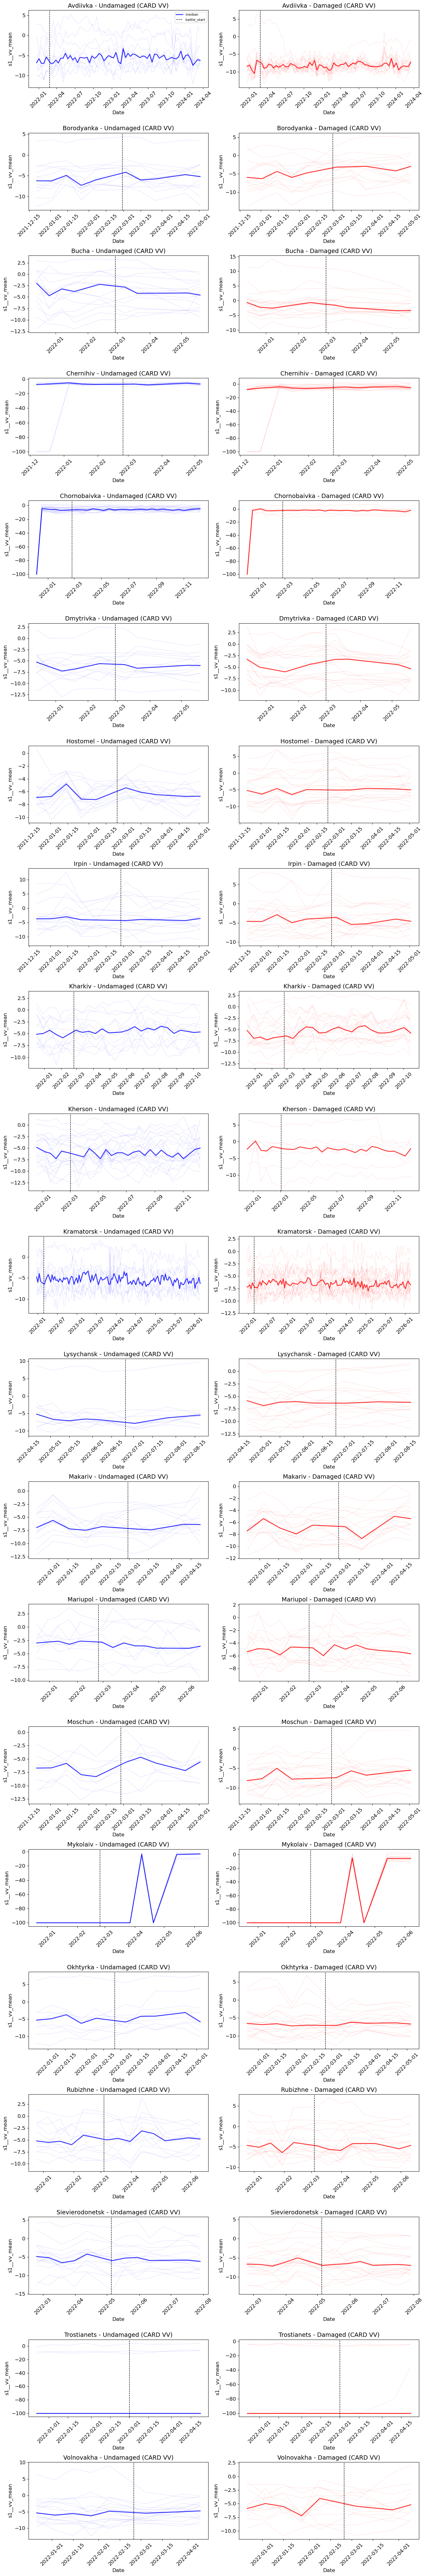

  Plot: cell_d7/trajectory_card_vv_20260417_213027.png
  load_tier_parquets: 3 tiers, 7087374 rows
  scene_coh: 3178910 rows, 414200 buildings, 18 cities
  COH date range: 2021-12-07 to 2024-03-05
  Plotting: s1__coh_vv_mean


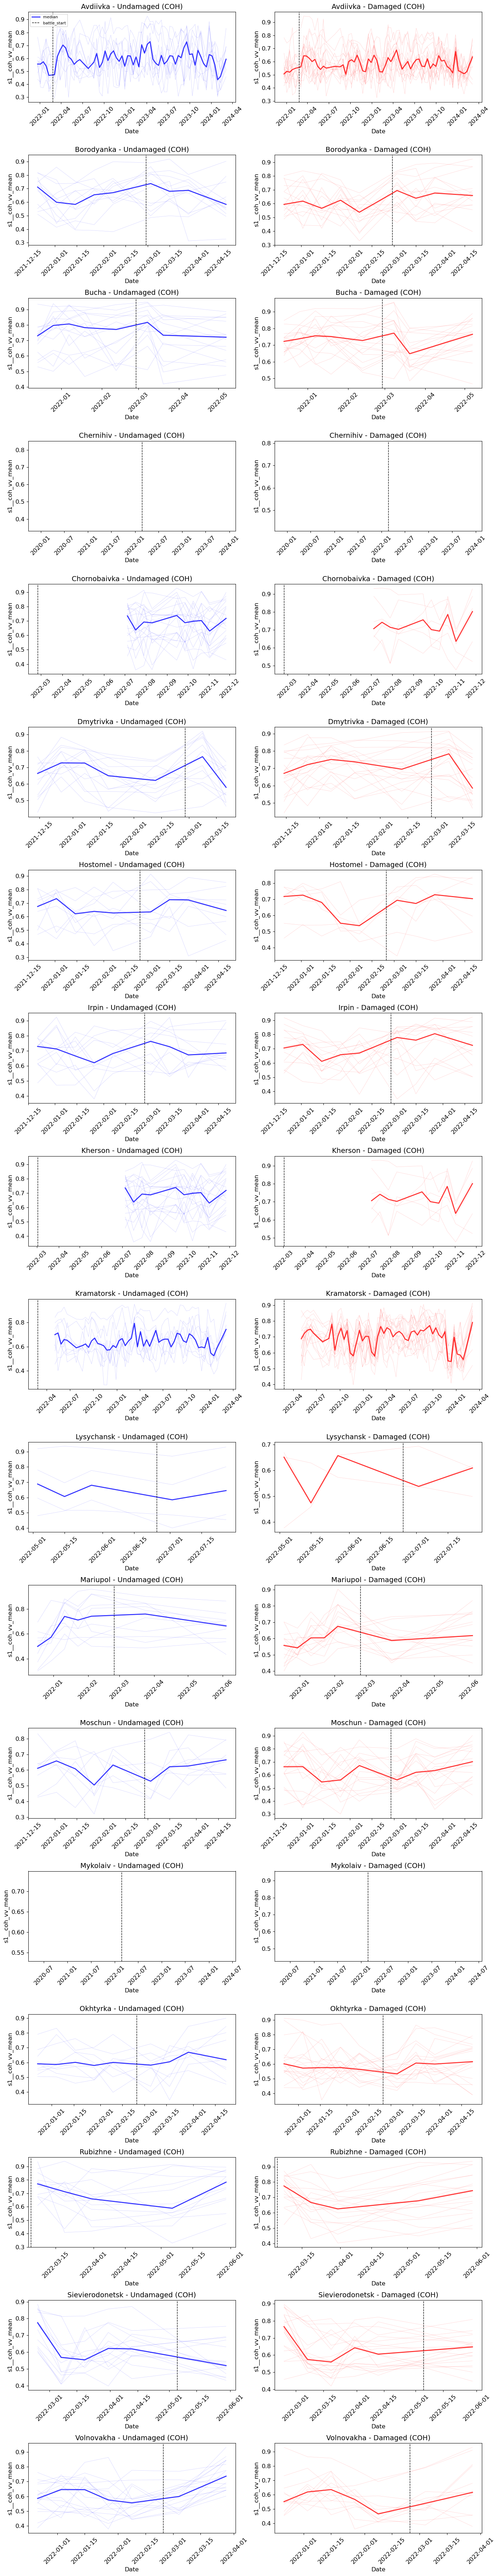

  Plot: cell_d7/trajectory_coh_20260417_213045.png


In [10]:
# @title CELL D7: TEMPORAL TRAJECTORY VISUALIZATION (bda_scene_card + bda_scene_coh)
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL D7: TEMPORAL TRAJECTORY VISUALIZATION")
print("=" * 70)

# load battle dates for vertical markers
battle_dates = {}
for city in CITIES_TO_PROCESS:
    aoi_path = CITIES_DIR / city / 'AOI.geojson'
    if aoi_path.exists():
        import re
        with open(aoi_path) as f:
            raw = f.read(50000)
        m = re.search(r'"battle_start"\s*:\s*"([^"]+)"', raw)
        if m:
            battle_dates[city] = pd.Timestamp(m.group(1))
if battle_dates:
    print(f"  Battle dates loaded for {len(battle_dates)} cities")

n_sample = 20


def plot_trajectories(df, value_col, date_col, sensor_label):
    """Plot damaged vs undamaged trajectories per city with battle_start marker."""
    cities = sorted(df['city'].unique())
    n_cities = len(cities)
    fig, axes = plt.subplots(n_cities, 2, figsize=(14, 4 * n_cities), squeeze=False)

    for row, city in enumerate(cities):
        df_city = df[df['city'] == city]
        dmg_ids = df_city[df_city[TARGET_COL] == 1]['building_id'].unique()
        undmg_ids = df_city[df_city[TARGET_COL] == 0]['building_id'].unique()
        np.random.seed(RANDOM_STATE)
        s_dmg = np.random.choice(dmg_ids, min(n_sample, len(dmg_ids)), replace=False) if len(dmg_ids) > 0 else []
        s_undmg = np.random.choice(undmg_ids, min(n_sample, len(undmg_ids)), replace=False) if len(undmg_ids) > 0 else []

        for col_idx, (ids, title, color) in enumerate([
            (s_undmg, 'Undamaged', 'blue'),
            (s_dmg, 'Damaged', 'red'),
        ]):
            ax = axes[row, col_idx]
            vals_by_date = {}
            for bid in ids:
                bdata = df_city[df_city['building_id'] == bid].sort_values(date_col)
                dates = bdata[date_col].values
                vals = bdata[value_col].values
                ax.plot(dates, vals, alpha=0.2, color=color, linewidth=0.5)
                for d, v in zip(dates, vals):
                    vals_by_date.setdefault(d, []).append(v)

            # median trajectory overlay
            if vals_by_date:
                sorted_dates = sorted(vals_by_date.keys())
                medians = [np.nanmedian(vals_by_date[d]) for d in sorted_dates]
                ax.plot(sorted_dates, medians, color=color, linewidth=2, alpha=0.8, label='median')

            # battle_start vertical line
            if city in battle_dates:
                ax.axvline(battle_dates[city], color='black', linestyle='--', linewidth=1, label='battle_start')

            ax.set_title(f'{city} - {title} ({sensor_label})')
            ax.set_xlabel('Date')
            ax.set_ylabel(value_col)
            ax.tick_params(axis='x', rotation=45)
            if col_idx == 0 and row == 0:
                ax.legend(fontsize=8)

    plt.tight_layout()
    save_fig(fig, f'trajectory_{sensor_label.lower().replace(" ", "_")}', 'cell_d7')


# CARD trajectories
try:
    df_sc = load_tier_parquets(PARQUET_SCENE_CARD_TIER_FMT, _tiers)
    city_list = [c for c in CITIES_TO_PROCESS if c in df_sc['city'].unique()]
    df_sc = df_sc[df_sc['city'].isin(city_list)]
    df_sc = df_sc.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                        on=['building_id', 'city'], how='inner')
    df_sc = df_sc[df_sc[TARGET_COL] >= 0]
    print(f"  scene_card: {len(df_sc)} rows, {df_sc['building_id'].nunique()} buildings, {df_sc['city'].nunique()} cities")

    # parse date column (YYYYMMDD string or integer)
    df_sc['_plot_date'] = pd.to_datetime(df_sc['date'].astype(str), format='%Y%m%d')
    print(f"  CARD date range: {df_sc['_plot_date'].min().date()} to {df_sc['_plot_date'].max().date()}")

    # value column: s1__vv_mean per schema
    vv_col = 's1__vv_mean' if 's1__vv_mean' in df_sc.columns else None
    if vv_col is None:
        vv_candidates = [c for c in df_sc.columns if 'vv' in c.lower() and c.endswith('_mean')
                         and 'zscore' not in c and 'ratio' not in c and 'roll' not in c]
        vv_col = vv_candidates[0] if vv_candidates else None

    if vv_col:
        print(f"  Plotting: {vv_col}")
        plot_trajectories(df_sc, vv_col, '_plot_date', 'CARD VV')
    else:
        print("  SKIP: no VV mean column found")
        print(f"  Available columns: {[c for c in df_sc.columns if c.startswith('s1__')]}")
    del df_sc
except FileNotFoundError:
    print("  SKIP: no scene_card tier parquets found")

# COH trajectories
try:
    df_coh = load_tier_parquets(PARQUET_SCENE_COH_TIER_FMT, _tiers)
    city_list = [c for c in CITIES_TO_PROCESS if c in df_coh['city'].unique()]
    df_coh = df_coh[df_coh['city'].isin(city_list)]
    df_coh = df_coh.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                          on=['building_id', 'city'], how='inner')
    df_coh = df_coh[df_coh[TARGET_COL] >= 0]
    print(f"  scene_coh: {len(df_coh)} rows, {df_coh['building_id'].nunique()} buildings, {df_coh['city'].nunique()} cities")

    # parse date1 column (YYYYMMDD string or integer) — COH uses date pairs
    df_coh['_plot_date'] = pd.to_datetime(df_coh['date1'].astype(str), format='%Y%m%d')
    print(f"  COH date range: {df_coh['_plot_date'].min().date()} to {df_coh['_plot_date'].max().date()}")

    # value column: s1__coh_vv_mean per schema
    coh_col = 's1__coh_vv_mean' if 's1__coh_vv_mean' in df_coh.columns else None
    if coh_col is None:
        coh_candidates = [c for c in df_coh.columns if 'coh' in c.lower() and c.endswith('_mean')
                          and 'zscore' not in c]
        coh_col = coh_candidates[0] if coh_candidates else None

    if coh_col:
        print(f"  Plotting: {coh_col}")
        plot_trajectories(df_coh, coh_col, '_plot_date', 'COH')
    else:
        print("  SKIP: no COH mean column found")
        print(f"  Available columns: {[c for c in df_coh.columns if c.startswith('s1__')]}")
    del df_coh
except FileNotFoundError:
    print("  SKIP: no scene_coh tier parquets found")

# CELL D8: TIER / PARQUET EXISTENCE DIAGNOSTIC
# Why does NB09a show only 4 cities despite TIER_SELECTION=[0,1,2]?
# Checks: file existence, row counts, damage label coverage per tier.


In [11]:
# @title CELL D8: TIER / PARQUET EXISTENCE DIAGNOSTIC
import pandas as pd
from pathlib import Path

print("=" * 70)
print("CELL D8: TIER / PARQUET EXISTENCE DIAGNOSTIC")
print("=" * 70)
print("  Why does NB09a report n_cities=4 with TIER_SELECTION=[0,1,2]?")

for tier in range(6):
    print(f"\n  --- TIER {tier} ---")

    # product_prepost (period-aggregated, 264 features)
    pp_path = Path(PARQUET_PREPOST_TIER_FMT.format(tier=tier))
    if pp_path.exists():
        df = pd.read_parquet(pp_path)
        cities = sorted(df['city'].unique()) if 'city' in df.columns else []
        has_dmg = 'damage_binary' in df.columns
        if has_dmg:
            n_pos = (df['damage_binary'] == 1).sum()
            n_neg = (df['damage_binary'] == 0).sum()
            n_unk = (df['damage_binary'] < 0).sum()
            n_nan = df['damage_binary'].isna().sum()
        else:
            n_pos = n_neg = n_unk = n_nan = '?'
        print(f"    product_prepost:  {len(df):>8d} rows, {len(df.columns):>4d} cols, {len(cities)} cities")
        print(f"      damage_binary:  pos={n_pos}, neg={n_neg}, unknown={n_unk}, NaN={n_nan}")
        print(f"      cities: {cities}")
        if has_dmg:
            for c in cities:
                cdf = df[df['city'] == c]
                d = (cdf['damage_binary'] == 1).sum()
                u = (cdf['damage_binary'] == 0).sum()
                k = (cdf['damage_binary'] < 0).sum()
                n = df[cdf.index].isna().all(axis=1).sum()
                print(f"        {c:25s} d={d:>5d} u={u:>5d} unk={k:>5d} allNaN_rows={n:>5d}")
        del df
    else:
        print(f"    product_prepost:  NOT FOUND ({pp_path.name})")

    # prepost_single (NB08b simple features)
    ps_path = Path(PARQUET_PREPOST_SINGLE_TIER_FMT.format(tier=tier))
    if ps_path.exists():
        df = pd.read_parquet(ps_path)
        cities = sorted(df['city'].unique()) if 'city' in df.columns else []
        has_dmg = 'damage_binary' in df.columns
        if has_dmg:
            n_pos = (df['damage_binary'] == 1).sum()
            n_neg = (df['damage_binary'] == 0).sum()
        else:
            n_pos = n_neg = '?'
        print(f"    prepost_single:   {len(df):>8d} rows, {len(df.columns):>4d} cols, {len(cities)} cities")
        print(f"      damage_binary:  pos={n_pos}, neg={n_neg}")
        print(f"      cities: {cities}")
        del df
    else:
        print(f"    prepost_single:   NOT FOUND ({ps_path.name})")

    # buildings
    bl_path = Path(PARQUET_BUILDINGS_TIER_FMT.format(tier=tier))
    if bl_path.exists():
        df = pd.read_parquet(bl_path)
        cities = sorted(df['city'].unique()) if 'city' in df.columns else []
        print(f"    buildings:        {len(df):>8d} rows, {len(cities)} cities")
        del df
    else:
        print(f"    buildings:        NOT FOUND")

print(f"\n{'='*70}")
print("DIAGNOSTIC: If product_prepost T1/T2 have 0 damage_binary=1,")
print("            then load_and_merge() drops all rows -> 4 cities only.")
print(f"{'='*70}")


CELL D8: TIER / PARQUET EXISTENCE DIAGNOSTIC
  Why does NB09a report n_cities=4 with TIER_SELECTION=[0,1,2]?

  --- TIER 0 ---
    product_prepost:    197114 rows,  348 cols, 4 cities
      damage_binary:  pos=?, neg=?, unknown=?, NaN=?
      cities: ['Lysychansk', 'Mariupol', 'Rubizhne', 'Sievierodonetsk']
    prepost_single:     197114 rows,   40 cols, 4 cities
      damage_binary:  pos=?, neg=?
      cities: ['Lysychansk', 'Mariupol', 'Rubizhne', 'Sievierodonetsk']
    buildings:          197114 rows, 4 cities

  --- TIER 1 ---
    product_prepost:    265550 rows,  348 cols, 11 cities
      damage_binary:  pos=?, neg=?, unknown=?, NaN=?
      cities: ['Borodyanka', 'Bucha', 'Chernihiv', 'Dmytrivka', 'Hostomel', 'Irpin', 'Makariv', 'Moschun', 'Okhtyrka', 'Trostianets', 'Volnovakha']
    prepost_single:     265550 rows,   40 cols, 11 cities
      damage_binary:  pos=?, neg=?
      cities: ['Borodyanka', 'Bucha', 'Chernihiv', 'Dmytrivka', 'Hostomel', 'Irpin', 'Makariv', 'Moschun', 'Okh

# CELL D9: PARQUET CROSS-COMPARISON (product_prepost vs prepost_single)
# Join both parquets on building_id for the same city.
# Check if period-aggregated features correlate with simple single-scene features.
# If not, period-aggregation is destroying signal.


In [12]:
# @title CELL D9: PARQUET CROSS-COMPARISON (product_prepost vs prepost_single)
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from sklearn.metrics import roc_auc_score

print("=" * 70)
print("CELL D9: PARQUET CROSS-COMPARISON")
print("=" * 70)

# load both for T0
try:
    df_pp = load_and_merge(PARQUET_PREPOST_TIER_FMT)
except Exception as e:
    print(f"  product_prepost load failed: {e}")
    df_pp = None

try:
    df_ps = load_tier_parquets(PARQUET_PREPOST_SINGLE_TIER_FMT, _tiers)
    if TARGET_COL not in df_ps.columns:
        df_ps = df_ps.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                            on=['building_id', 'city'], how='inner')
    df_ps = df_ps[df_ps[TARGET_COL] >= 0].copy()
except Exception as e:
    print(f"  prepost_single load failed: {e}")
    df_ps = None

if df_pp is not None and df_ps is not None:
    common_cities = sorted(set(df_pp['city'].unique()) & set(df_ps['city'].unique()))
    print(f"  product_prepost: {len(df_pp)} rows, {df_pp['city'].nunique()} cities, {len(df_pp.columns)} cols")
    print(f"  prepost_single:  {len(df_ps)} rows, {df_ps['city'].nunique()} cities, {len(df_ps.columns)} cols")
    print(f"  Common cities:   {common_cities}")

    # feature columns in each
    _meta = {'building_id', 'city', 'tier', TARGET_COL, 'damage_label', 'damage',
             'centroid_x', 'centroid_y', 'area_m2', 'n_pixels', 'height',
             'num_floors', 'roof_height', 'unosat_id', 'unosat_date', 'unosat_ep',
             'match_method', 'match_distance', 'in_aoi', 'battle_start', 'battle_stop',
             'conflict_ongoing', 'has_card', 'has_coh', 'has_ms', 'ems98_grade'}
    pp_feats = [c for c in df_pp.columns if c not in _meta]
    ps_feats = [c for c in df_ps.columns if c not in _meta]
    print(f"\n  product_prepost features ({len(pp_feats)}): {pp_feats[:8]}...")
    print(f"  prepost_single  features ({len(ps_feats)}): {ps_feats[:8]}...")

    for CITY in common_cities:
        print(f"\n  {'='*60}")
        print(f"  {CITY}")
        print(f"  {'='*60}")

        pp_city = df_pp[df_pp['city'] == CITY].copy()
        ps_city = df_ps[df_ps['city'] == CITY].copy()

        # join on building_id
        merged = pp_city.merge(ps_city, on='building_id', suffixes=('_pp', '_ps'), how='inner')
        print(f"    Joined: {len(merged)} buildings (pp={len(pp_city)}, ps={len(ps_city)})")

        if len(merged) < 50:
            print(f"    SKIP: too few matched buildings")
            continue

        y = merged[f'{TARGET_COL}_pp'].values if f'{TARGET_COL}_pp' in merged.columns else merged[TARGET_COL].values

        # --- A. Per-feature AUC on product_prepost (single city) ---
        print(f"\n    A. Per-feature AUC on product_prepost ({CITY} only):")
        pp_auc_rows = []
        for col in pp_feats:
            col_m = f"{col}_pp" if f"{col}_pp" in merged.columns else col
            if col_m not in merged.columns:
                continue
            valid = merged[[col_m]].dropna()
            idx = valid.index
            vals = merged.loc[idx, col_m].values
            yt = y[merged.index.get_indexer(idx)]
            if len(vals) < 50 or len(np.unique(yt)) < 2:
                continue
            try:
                auc = roc_auc_score(yt, vals)
                auc_best = max(auc, 1 - auc)
                pp_auc_rows.append({'feature': col, 'auc_best': auc_best, 'auc_raw': auc, 'n': len(vals)})
            except:
                pass
        if pp_auc_rows:
            pp_auc = pd.DataFrame(pp_auc_rows).sort_values('auc_best', ascending=False)
            mean_auc = pp_auc['auc_best'].mean()
            below_random = (pp_auc['auc_best'] < 0.52).sum()
            print(f"      {len(pp_auc)} features tested, mean AUC={mean_auc:.3f}, below_random(<0.52)={below_random}")
            print(f"      Top 10:")
            for _, r in pp_auc.head(10).iterrows():
                print(f"        {r['feature']:55s} AUC={r['auc_best']:.3f} (n={int(r['n'])})")
            print(f"      Bottom 5:")
            for _, r in pp_auc.tail(5).iterrows():
                print(f"        {r['feature']:55s} AUC={r['auc_best']:.3f}")
            if mean_auc < 0.52:
                print(f"      *** ALARM: mean AUC {mean_auc:.3f} < 0.52 -> features are near-random ***")

        # --- B. Per-feature AUC on prepost_single (single city) ---
        print(f"\n    B. Per-feature AUC on prepost_single ({CITY} only):")
        ps_auc_rows = []
        for col in ps_feats:
            col_m = f"{col}_ps" if f"{col}_ps" in merged.columns else col
            if col_m not in merged.columns:
                continue
            valid = merged[[col_m]].dropna()
            idx = valid.index
            vals = merged.loc[idx, col_m].values
            yt = y[merged.index.get_indexer(idx)]
            if len(vals) < 50 or len(np.unique(yt)) < 2:
                continue
            try:
                auc = roc_auc_score(yt, vals)
                auc_best = max(auc, 1 - auc)
                ps_auc_rows.append({'feature': col, 'auc_best': auc_best, 'auc_raw': auc, 'n': len(vals)})
            except:
                pass
        if ps_auc_rows:
            ps_auc = pd.DataFrame(ps_auc_rows).sort_values('auc_best', ascending=False)
            print(f"      {len(ps_auc)} features tested, mean AUC={ps_auc['auc_best'].mean():.3f}")
            for _, r in ps_auc.head(10).iterrows():
                print(f"        {r['feature']:55s} AUC={r['auc_best']:.3f}")

        # --- C. Cross-correlation between matching features ---
        print(f"\n    C. Feature cross-correlation (product_prepost vs prepost_single):")
        # try to find semantic matches
        candidate_pairs = [
            ('s1__vv__assessment__mean_mean', 'post_vv_mean'),
            ('s1__vh__assessment__mean_mean', 'post_vh_mean'),
            ('s1__vv__baseline__mean_mean',   'pre_vv_mean'),
            ('s1__vh__baseline__mean_mean',   'pre_vh_mean'),
        ]
        for pp_col, ps_col in candidate_pairs:
            pp_m = f"{pp_col}_pp" if f"{pp_col}_pp" in merged.columns else pp_col
            ps_m = f"{ps_col}_ps" if f"{ps_col}_ps" in merged.columns else ps_col
            if pp_m not in merged.columns or ps_m not in merged.columns:
                # fuzzy match: search for partial match
                pp_matches = [c for c in merged.columns if pp_col.split('__')[-1] in c and '_pp' in c]
                ps_matches = [c for c in merged.columns if ps_col in c and '_ps' in c]
                if not pp_matches or not ps_matches:
                    print(f"      {pp_col:45s} vs {ps_col:20s} -> NOT FOUND")
                    continue
                pp_m = pp_matches[0]
                ps_m = ps_matches[0]
            valid = merged[[pp_m, ps_m]].dropna()
            if len(valid) < 20:
                print(f"      {pp_col:45s} vs {ps_col:20s} -> too few valid ({len(valid)})")
                continue
            r, p = scipy_stats.pearsonr(valid[pp_m], valid[ps_m])
            pp_range = f"[{valid[pp_m].min():.3f}, {valid[pp_m].max():.3f}]"
            ps_range = f"[{valid[ps_m].min():.3f}, {valid[ps_m].max():.3f}]"
            flag = " *** LOW ***" if abs(r) < 0.5 else ""
            print(f"      {pp_col:45s} vs {ps_col:20s}  r={r:+.3f} p={p:.1e}{flag}")
            print(f"        pp range={pp_range}  ps range={ps_range}")

        # --- D. Column name audit ---
        print(f"\n    D. Column name audit:")
        # check for city-prefix contamination (the bug from stack_features.py)
        city_prefix_cols = [c for c in pp_feats if CITY.lower() in c.lower() or CITY in c]
        if city_prefix_cols:
            print(f"      *** FOUND city-prefix columns ({len(city_prefix_cols)}): {city_prefix_cols[:5]} ***")
            print(f"      This is the stack_features.py bug. NB05 rerun required.")
        else:
            print(f"      No city-prefix columns found (good)")

        # check for columns that are 100% NaN for this city
        all_nan_cols = [c for c in pp_feats if c in pp_city.columns and pp_city[c].isna().all()]
        partial_nan_cols = [c for c in pp_feats if c in pp_city.columns and pp_city[c].isna().any() and not pp_city[c].isna().all()]
        print(f"      All-NaN: {len(all_nan_cols)}/{len(pp_feats)} columns")
        print(f"      Partial-NaN: {len(partial_nan_cols)}/{len(pp_feats)} columns")
        if all_nan_cols:
            print(f"      All-NaN examples: {all_nan_cols[:10]}")

    # save cross-comparison
    if pp_auc_rows:
        save_result(pd.DataFrame(pp_auc_rows), 'product_prepost_single_city_auc', 'cell_d9')
    if ps_auc_rows:
        save_result(pd.DataFrame(ps_auc_rows), 'prepost_single_single_city_auc', 'cell_d9')

    # registry
    if pp_auc_rows and ps_auc_rows:
        registry.log_statistics(
            cell_id='cell_d9',
            analysis_name='parquet_cross_comparison',
            parquet_name='product_prepost+prepost_single',
            tier_selection=_tiers,
            cities=common_cities,
            n_buildings=len(merged) if 'merged' in dir() else None,
            summary_metrics={
                'pp_mean_auc': float(pd.DataFrame(pp_auc_rows)['auc_best'].mean()),
                'ps_mean_auc': float(pd.DataFrame(ps_auc_rows)['auc_best'].mean()),
                'pp_n_features': len(pp_auc_rows),
                'ps_n_features': len(ps_auc_rows),
                'delta_mean_auc': float(pd.DataFrame(ps_auc_rows)['auc_best'].mean() - pd.DataFrame(pp_auc_rows)['auc_best'].mean()),
            },
            note='Cross-comparison: product_prepost vs prepost_single on same buildings',
            tags=['diagnostic', 'corruption', 'cross_comparison'],
        )

    del df_pp, df_ps
else:
    print("  Cannot run cross-comparison: one or both parquets failed to load")


CELL D9: PARQUET CROSS-COMPARISON
  load_tier_parquets: 3 tiers, 907371 rows
  load_tier_parquets: 3 tiers, 907371 rows
  product_prepost: 598595 rows, 21 cities, 349 cols
  prepost_single:  598595 rows, 21 cities, 41 cols
  Common cities:   ['Avdiivka', 'Borodyanka', 'Bucha', 'Chernihiv', 'Chornobaivka', 'Dmytrivka', 'Hostomel', 'Irpin', 'Kharkiv', 'Kherson', 'Kramatorsk', 'Lysychansk', 'Makariv', 'Mariupol', 'Moschun', 'Mykolaiv', 'Okhtyrka', 'Rubizhne', 'Sievierodonetsk', 'Trostianets', 'Volnovakha']

  product_prepost features (346): ['s1__vh__assessment__count_mean', 's1__vh__assessment__count_std', 's1__vh__assessment__count_max', 's1__vh__assessment__kurtosis_mean', 's1__vh__assessment__kurtosis_std', 's1__vh__assessment__kurtosis_max', 's1__vh__assessment__max_mean', 's1__vh__assessment__max_std']...
  prepost_single  features (36): ['pre_r_mean', 'pre_r_std', 'pre_g_mean', 'pre_g_std', 'pre_b_mean', 'pre_b_std', 'post_r_mean', 'post_r_std']...

  Avdiivka
    Joined: 12523 bui

# CELL D10: FEATURE VALUE SANITY CHECK
# Are product_prepost feature values in physically plausible ranges?
# CARD backscatter should be dB (-30 to +5). COH should be 0-1.
# If values are 0.0001-scale or 10000-scale, something is wrong.


In [13]:
# @title CELL D10: FEATURE VALUE SANITY CHECK
import numpy as np
import pandas as pd

print("=" * 70)
print("CELL D10: FEATURE VALUE SANITY CHECK")
print("=" * 70)

df_pp = load_and_merge(PARQUET_PREPOST_TIER_FMT)
from stack_loader import get_feature_groups
feature_groups = get_feature_groups(df_pp)

# expected physical ranges
EXPECTED_RANGES = {
    'card': {'min': -35.0, 'max': 10.0, 'desc': 'backscatter dB'},
    'coh':  {'min': 0.0,   'max': 1.0,  'desc': 'coherence'},
    'comp': {'min': 0.0,   'max': 1.0,  'desc': 'reflectance'},
    'idx':  {'min': -1.0,  'max': 1.0,  'desc': 'spectral index'},
    'lu':   {'min': 0.0,   'max': 10.0, 'desc': 'class code'},
}

anomalies = []

print(f"\n  {'Group':35s} {'N cols':>6s} {'NaN%':>6s} {'Min':>10s} {'Max':>10s} {'Mean':>10s} {'Range OK?'}")
print(f"  {'-'*35} {'-'*6} {'-'*6} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")

for gname, cols in sorted(feature_groups.items()):
    if gname == 'meta' or not cols:
        continue
    data = df_pp[cols]
    nan_pct = data.isna().mean().mean() * 100
    vals = data.values.flatten()
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        print(f"  {gname:35s} {len(cols):>6d} {nan_pct:>5.1f}% {'ALL NaN':>10s}")
        anomalies.append({'group': gname, 'issue': 'all_nan', 'n_cols': len(cols)})
        continue
    vmin = float(np.min(vals))
    vmax = float(np.max(vals))
    vmean = float(np.mean(vals))

    # check against expected range
    range_ok = '?'
    for prefix, expected in EXPECTED_RANGES.items():
        if gname.startswith(prefix) or prefix in gname:
            if vmin >= expected['min'] - 5 and vmax <= expected['max'] + 5:
                range_ok = 'OK'
            else:
                range_ok = f"SUSPECT ({expected['desc']})"
                anomalies.append({
                    'group': gname, 'issue': 'range_violation',
                    'expected': f"{expected['min']} to {expected['max']}",
                    'actual': f"{vmin:.3f} to {vmax:.3f}",
                    'n_cols': len(cols),
                })
            break

    print(f"  {gname:35s} {len(cols):>6d} {nan_pct:>5.1f}% {vmin:>10.3f} {vmax:>10.3f} {vmean:>10.3f} {range_ok}")

# constant or near-constant features (dead signal)
print(f"\n  Constant / near-constant features (std < 1e-6):")
dead_feats = []
for gname, cols in sorted(feature_groups.items()):
    if gname == 'meta':
        continue
    for c in cols:
        if c not in df_pp.columns:
            continue
        vals = df_pp[c].dropna().values
        if len(vals) < 20:
            continue
        if np.std(vals) < 1e-6:
            dead_feats.append(c)
if dead_feats:
    print(f"    {len(dead_feats)} dead features:")
    for f in dead_feats[:20]:
        v = df_pp[f].dropna()
        print(f"      {f:55s} value={v.iloc[0]:.6f} (n={len(v)})")
    anomalies.append({'group': 'various', 'issue': 'constant_features', 'n_cols': len(dead_feats)})
else:
    print(f"    None found (good)")

# summary
print(f"\n{'='*70}")
if anomalies:
    print(f"ANOMALIES FOUND ({len(anomalies)}):")
    for a in anomalies:
        print(f"  {a['group']:35s} {a['issue']:20s} n_cols={a['n_cols']}")
else:
    print("NO ANOMALIES FOUND -- feature ranges look physically plausible")
print(f"{'='*70}")

if anomalies:
    save_result(pd.DataFrame(anomalies), 'feature_anomalies', 'cell_d10')
    registry.log_statistics(
        cell_id='cell_d10',
        analysis_name='feature_value_sanity_check',
        parquet_name='bda_product_prepost',
        tier_selection=_tiers,
        cities=sorted(df_pp['city'].unique().tolist()),
        n_features_tested=sum(len(v) for k, v in feature_groups.items() if k != 'meta'),
        summary_metrics={
            'n_anomalies': len(anomalies),
            'n_dead_features': len(dead_feats),
        },
        results_records=anomalies,
        note='Feature value range + constant check',
        tags=['diagnostic', 'sanity_check', 'corruption'],
    )

del df_pp


CELL D10: FEATURE VALUE SANITY CHECK
  load_tier_parquets: 3 tiers, 907371 rows

  Group                               N cols   NaN%        Min        Max       Mean Range OK?
  ----------------------------------- ------ ------ ---------- ---------- ---------- ----------
  card_assessment                         48  53.6%   -100.000     50.448     -3.069 SUSPECT (backscatter dB)
  card_baseline                           48  38.5%   -100.000     57.409     -7.138 SUSPECT (backscatter dB)
  coh_baseline                            18  83.0%     -0.062      4.000      0.769 OK
  comp_other                              45  48.7%      0.000      1.000      0.139 OK
  comp_post_winter_baseline               49  53.7%     -0.635      6.000      0.318 OK
  comp_prebattle_baseline                 49  48.2%     -0.665      6.000      0.350 OK
  comp_winter_baseline                    49  48.2%     -0.665      6.000      0.343 OK
  other                                   40  69.1%    -53.671    12

In [14]:
import rasterio, numpy as np
from pathlib import Path

city = 'Borodyanka'
card_dir = STACK_DIR / city / 'SAR_CARD'
if not card_dir.exists():
    card_dir = SAR_CARD_DIR / city

tifs = sorted(card_dir.rglob('*vv*.tif'))[:10]
for t in tifs:
    with rasterio.open(t) as src:
        data = src.read(1)
        pct_nan = 100 * np.isnan(data).sum() / data.size
        finite = data[np.isfinite(data)]
        if len(finite) > 0:
            print(f"  {t.name}: {pct_nan:.0f}% NaN, finite min={finite.min():.1f} max={finite.max():.1f} mean={finite.mean():.1f}")
        else:
            print(f"  {t.name}: 100% NaN (no coverage)")

  s1__vv__card_prepost__delta.tif: 0% NaN, finite min=-20.7 max=22.6 mean=-0.3
  s1__vv__card_prepost__post__20220420.tif: 0% NaN, finite min=-29.6 max=28.7 mean=-10.6
  s1__vv__card_prepost__pre__20220207.tif: 0% NaN, finite min=-24.6 max=28.3 mean=-10.3
  s1__vv__20211221.tif: 0% NaN, finite min=-28.6 max=19.5 mean=-10.6
  s1__vv__20220102.tif: 0% NaN, finite min=-30.2 max=27.9 mean=-11.0
  s1__vv__20220114.tif: 0% NaN, finite min=-27.6 max=28.3 mean=-8.5
  s1__vv__20220126.tif: 0% NaN, finite min=-28.0 max=18.8 mean=-11.8
  s1__vv__20220207.tif: 0% NaN, finite min=-24.6 max=28.3 mean=-10.3
  s1__vv__20220303.tif: 0% NaN, finite min=-27.9 max=28.1 mean=-8.9
  s1__vv__20220315.tif: 0% NaN, finite min=-29.3 max=28.3 mean=-9.5


In [15]:
# @title CELL 19: SAVE REGISTRY
import importlib
import bda_results
importlib.reload(bda_results)
registry.__class__ = bda_results.ResultRegistry
registry.save()

  SAVED: NB07_experiments_20260417_200910.json (8 experiments)
  SAVED: NB07_experiments_20260417_200910.csv


PosixPath('/content/drive_f/masterthesis/results/registry')